# Predictive Maintenance Dataset Exploration

This notebook explores the predictive maintenance dataset used for the F20DX Data Mining and Machine Learning coursework project.

The purpose of this notebook is to:
- inspect the dataset structure
- identify potential preprocessing requirements
- investigate class imbalance
- explore feature relationships
- identify possible challenges for machine learning models

# Library Imports and Dataset Loading

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('predictive_maintenance.csv')

ModuleNotFoundError: No module named 'google'

# Initial Dataset Inspection

The first step is to inspect the structure of the dataset, including:

- available features

- feature data types

- potential missing values

- target variables

In [8]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB


# Target Class Distribution

The dataset target variable is analysed to determine whether class imbalance exists between machine failure and non-failure observations.

In [3]:
df['Target'].value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

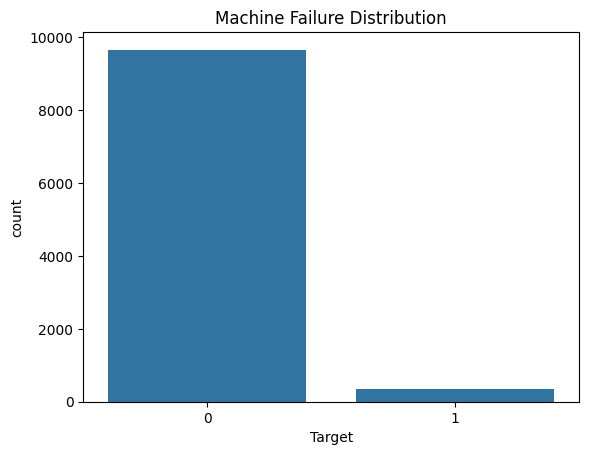

In [4]:
sns.countplot(x='Target', data=df)

plt.title('Machine Failure Distribution')

plt.show()

## Observations

The dataset is highly imbalanced, with significantly more non-failure observations than failure observations.

This imbalance is important because classification models may achieve artificially high accuracy by predominantly predicting the majority class.

For this reason, evaluation metrics such as precision, recall, F1-score, and confusion matrices will be used later in the project.

# Correlation Analysis

Correlation analysis was performed to investigate relationships between numerical features within the predictive maintenance dataset.

In [9]:
corr_df = df.drop(columns=['UDI', 'Product ID', 'Failure Type'])

corr_df = pd.get_dummies(corr_df, columns=['Type'])

corr_df = corr_df.astype(int, errors='ignore')

In [10]:
correlation_matrix = corr_df.corr()

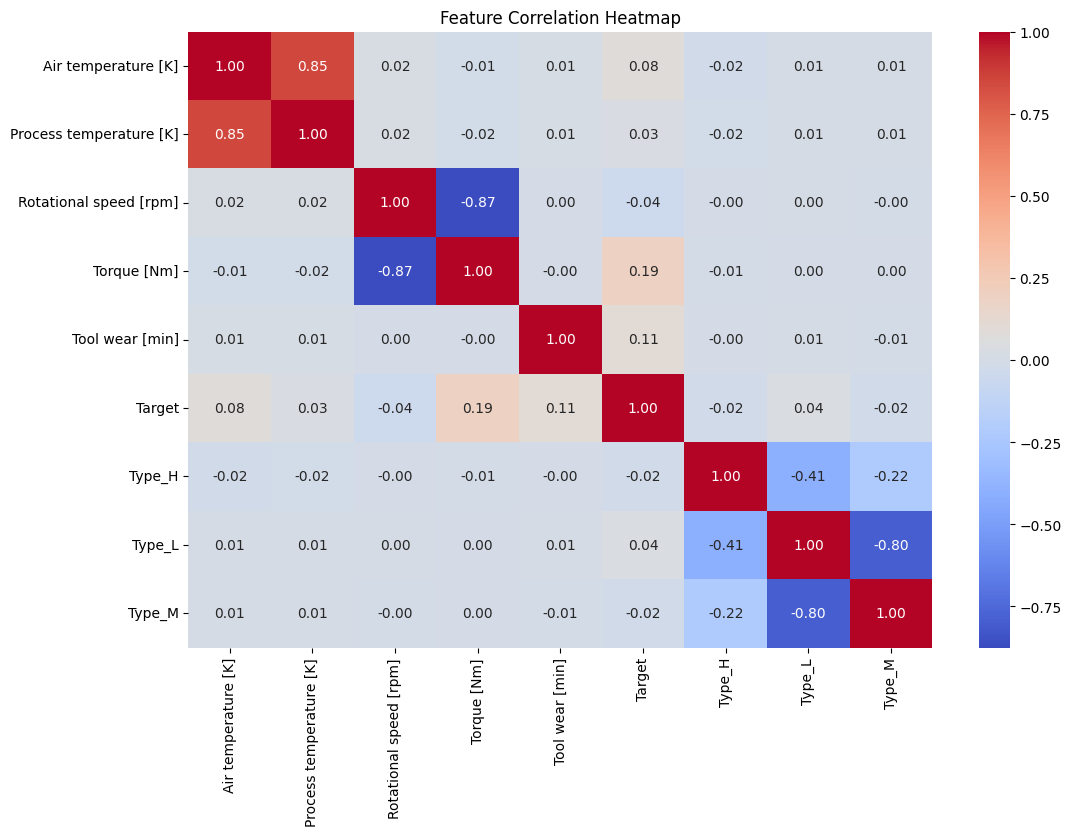

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')

plt.show()

## Correlation Analysis Discussion

Correlation analysis revealed several meaningful relationships between operational variables.

Air temperature and process temperature showed a strong positive correlation, which is physically reasonable because process temperatures are influenced by surrounding environmental conditions.

Rotational speed and torque exhibited a strong negative correlation. This likely reflects the inverse relationship between rotational velocity and torque observed in approximately constant-power mechanical systems.

Correlations between individual features and the target variable were generally weak, suggesting that machine failures depend on complex interactions between multiple operational factors rather than a single dominant variable.

This may help explain why the Decision Tree classifier performed relatively well, as tree-based models are capable of capturing non-linear feature interactions.